In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("social_media_engagement_5000.csv")

# Display first 5 records
print("First 5 rows:")
display(df.head())

# Display last 5 records
print("Last 5 rows:")
display(df.tail())

# Dataset shape
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Information about dataset
print("\nDataset Information:")
df.info()

# Convert posted_at to datetime
df["posted_at"] = pd.to_datetime(
    df["posted_at"],
    dayfirst=True,
    errors="coerce"
)

# Check data types
print("\nData Types:")
print(df.dtypes)

# NumPy operations
likes_array = np.array(df["likes"].dropna())

print("\nNumPy Operations")
print("Total Likes:", np.sum(likes_array))
print("Average Likes:", np.mean(likes_array))
print("Maximum Likes:", np.max(likes_array))
print("Minimum Likes:", np.min(likes_array))

First 5 rows:


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


Last 5 rows:


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,04-03-2023,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527


Shape: (5000, 19)

Columns:
['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5

In [3]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


In [4]:
# Numerical columns - fill with median
numeric_columns = ["age", "likes", "comments", "shares"]

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns - fill with mode
categorical_columns = ["gender", "sentiment"]

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64


In [5]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after removal:", df.duplicated().sum())

Duplicate rows: 0
Duplicates after removal: 0


In [6]:
category_columns = [
    "gender",
    "country",
    "post_type",
    "post_category",
    "device_type",
    "sentiment"
]

for col in category_columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

print(df["gender"].unique())
print(df["sentiment"].unique())

['female' 'male' 'other']
['negative' 'positive' 'neutral']


In [7]:
print("Negative likes:", (df["likes"] < 0).sum())
print("Negative comments:", (df["comments"] < 0).sum())
print("Negative shares:", (df["shares"] < 0).sum())

Negative likes: 0
Negative comments: 0
Negative shares: 0


In [8]:
df["hashtag_count"] = (
    df["hashtags"]
    .fillna("")
    .str.findall(r"#\w+")
    .str.len()
)

display(df[["hashtags", "hashtag_count"]].head(10))

,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1
5,#fitness,1
6,#music,1
7,#travel #music #fitness,3
8,#music #fun #fitness,3
9,#lifestyle #love,2


In [9]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nData Types:")
print(df.dtypes)

Shape: (5000, 20)

Columns:
['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'hashtag_count']

First 5 rows:


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43.0,female,brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33.0,male,brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32.0,female,uk,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51.0,other,france,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34.0,other,uk,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1



Last 5 rows:


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44.0,male,australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38.0,other,uae,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63.0,female,usa,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13.0,female,germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54.0,other,japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3



Data Types:
user_id                      int64
age                        float64
gender                      object
country                     object
post_id                      int64
post_type                   object
post_category               object
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count               int64
is_verified                   bool
device_type                 object
sentiment                   object
hashtags                    object
engagement_rate            float64
hashtag_count                int64
dtype: object


In [10]:
display(df.describe())

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.687151,260646.957267,5702.293017,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [11]:
print("Post Types:")
print(df["post_type"].value_counts())

print("\nPost Categories:")
print(df["post_category"].value_counts())

print("\nGender:")
print(df["gender"].value_counts())

print("\nSentiment:")
print(df["sentiment"].value_counts())

print("\nCountries:")
print(df["country"].value_counts())

Post Types:
post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64

Post Categories:
post_category
fitness      675
tech         665
music        635
education    631
lifestyle    607
travel       600
fashion      594
food         593
Name: count, dtype: int64

Gender:
gender
male      1849
other     1581
female    1570
Name: count, dtype: int64

Sentiment:
sentiment
positive    2513
neutral     1527
negative     960
Name: count, dtype: int64

Countries:
country
india        535
canada       513
brazil       504
uae          503
usa          501
france       496
uk           493
australia    493
germany      490
japan        472
Name: count, dtype: int64


In [12]:
print("Unique post types:")
print(df["post_type"].unique())

print("\nNumber of post types:")
print(df["post_type"].nunique())

print("\nUnique categories:")
print(df["post_category"].unique())

print("\nNumber of categories:")
print(df["post_category"].nunique())

Unique post types:
['image' 'reel' 'text' 'video']

Number of post types:
4

Unique categories:
['fitness' 'food' 'tech' 'travel' 'fashion' 'lifestyle' 'education'
 'music']

Number of categories:
8


In [13]:
numeric_data = df.select_dtypes(include=np.number)

correlation_matrix = numeric_data.corr()

display(correlation_matrix)

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,-0.004282,-0.013692
age,-0.006688,1.000000,-0.013153,-0.036322,-0.007284,0.013871,0.005542,0.013322,-0.024894,0.008039,0.007173
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.010139,0.007344
likes,0.025811,-0.036322,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093520,-0.002190
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051,-0.015230
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724,0.013379
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148,-0.023301
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226,-0.002714
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292,0.008802
engagement_rate,-0.004282,0.008039,0.010139,0.093520,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000,0.005319


In [14]:
avg_likes_post_type = (
    df.groupby("post_type")["likes"]
    .mean()
    .sort_values(ascending=False)
)

display(avg_likes_post_type)

,likes
post_type,
video,10188.600000
image,10104.865277
text,10100.148193
reel,10037.802416


In [15]:
avg_engagement_country = (
    df.groupby("country")["engagement_rate"]
    .mean()
    .sort_values(ascending=False)
)

display(avg_engagement_country)

,engagement_rate
country,
brazil,1.540704
australia,1.324339
france,1.146402
uae,1.112352
canada,0.916659
uk,0.850966
japan,0.769623
germany,0.759000
india,0.655005


In [16]:
df["engagement_score"] = (
    df["likes"] +
    df["comments"] +
    df["shares"]
)

display(
    df[
        ["likes", "comments", "shares", "engagement_score"]
    ].head()
)

,likes,comments,shares,engagement_score
0,7011.0,354.0,1157.0,8522.0
1,11750.0,2606.0,1807.0,16163.0
2,4862.0,344.0,955.0,6161.0
3,5350.0,1083.0,1049.0,7482.0
4,12682.0,2735.0,1300.0,16717.0


In [17]:
post_type_summary = df.groupby("post_type").agg({
    "likes": "mean",
    "comments": "mean",
    "shares": "mean",
    "engagement_rate": "mean"
}).sort_values(
    "engagement_rate",
    ascending=False
)

display(post_type_summary)

,likes,comments,shares,engagement_rate
post_type,,,,
video,10188.600000,1479.160000,996.834286,1.122365
text,10100.148193,1499.106024,1013.989558,1.064549
image,10104.865277,1525.235766,1019.289495,0.895646
reel,10037.802416,1504.187062,982.042089,0.783047


In [18]:
country_summary = df.groupby("country").agg({
    "likes": "mean",
    "comments": "mean",
    "shares": "mean",
    "engagement_rate": "mean"
}).sort_values(
    "engagement_rate",
    ascending=False
)

display(country_summary)

,likes,comments,shares,engagement_rate
country,,,,
brazil,9886.689484,1490.434524,1008.859127,1.540704
australia,10294.124746,1485.803245,1029.693712,1.324339
france,10372.876008,1478.695565,1051.812500,1.146402
uae,10227.487078,1541.214712,989.075547,1.112352
canada,10063.066277,1546.582846,996.245614,0.916659
uk,9935.650101,1463.042596,985.681542,0.850966
japan,10088.862288,1530.434322,959.351695,0.769623
germany,10130.458163,1531.826531,973.379592,0.759000
india,9962.468224,1494.917757,1035.315888,0.655005


In [19]:
sentiment_summary = df.groupby("sentiment").agg({
    "likes": "mean",
    "comments": "mean",
    "shares": "mean",
    "engagement_rate": "mean"
}).sort_values(
    "engagement_rate",
    ascending=False
)

display(sentiment_summary)

,likes,comments,shares,engagement_rate
sentiment,,,,
negative,10208.096875,1516.094792,1007.307292,1.038486
neutral,9923.194499,1528.404060,996.565160,0.991170
positive,10180.062077,1480.650617,1005.086749,0.919744


In [20]:
metrics = [
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "engagement_rate",
    "follower_count"
]

for column in metrics:

    print("\n==============================")
    print(column.upper())
    print("==============================")

    print("Mean:", df[column].mean())
    print("Median:", df[column].median())
    print("Mode:", df[column].mode().iloc[0])
    print("Standard Deviation:", df[column].std())
    print("Variance:", df[column].var())
    print("25th Percentile:", df[column].quantile(0.25))
    print("50th Percentile:", df[column].quantile(0.50))
    print("75th Percentile:", df[column].quantile(0.75))


LIKES
Mean: 10106.9974
Median: 10105.5
Mode: 10105.5
Standard Deviation: 5702.293017183876
Variance: 32516145.653823998
25th Percentile: 5235.0
50th Percentile: 10105.5
75th Percentile: 14959.0

COMMENTS
Mean: 1502.0398
Median: 1497.0
Mode: 1497.0
Standard Deviation: 856.3933120458967
Variance: 733409.5049169405
25th Percentile: 792.0
50th Percentile: 1497.0
75th Percentile: 2235.25

SHARES
Mean: 1002.9106
Median: 1012.0
Mode: 1012.0
Standard Deviation: 570.8551999758862
Variance: 325875.65933950903
25th Percentile: 511.0
50th Percentile: 1012.0
75th Percentile: 1483.0

WATCH_TIME_SEC
Mean: 4014.5032
Median: 4034.5
Mode: 916
Standard Deviation: 2308.096459042085
Variance: 5327309.26424261
25th Percentile: 2017.75
50th Percentile: 4034.5
75th Percentile: 6020.25

ENGAGEMENT_RATE
Mean: 0.9643560291583999
Median: 0.2538959065
Mode: 0.006362909
Standard Deviation: 5.318029222661535
Variance: 28.281434813082043
25th Percentile: 0.14578108750000002
50th Percentile: 0.2538959065
75th Percent

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

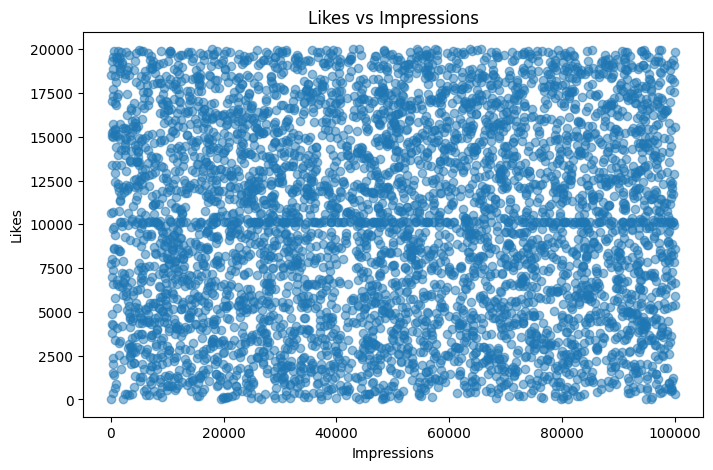

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["impression_count"],
    df["likes"],
    alpha=0.5
)

plt.xlabel("Impressions")
plt.ylabel("Likes")
plt.title("Likes vs Impressions")
plt.show()

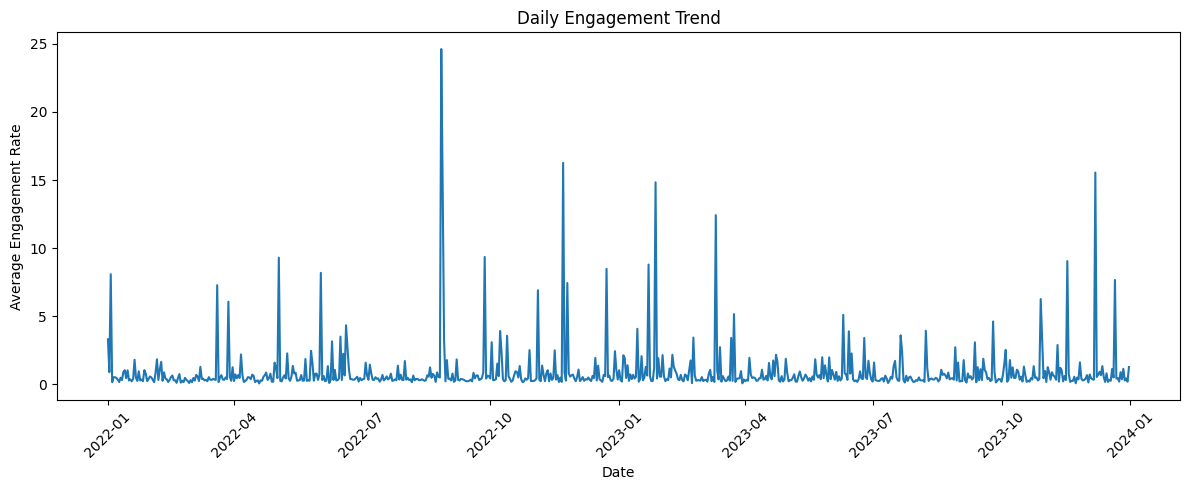

In [23]:
daily_engagement = (
    df.groupby(df["posted_at"].dt.date)["engagement_rate"]
    .mean()
)

plt.figure(figsize=(12,5))

plt.plot(
    daily_engagement.index,
    daily_engagement.values
)

plt.xlabel("Date")
plt.ylabel("Average Engagement Rate")
plt.title("Daily Engagement Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

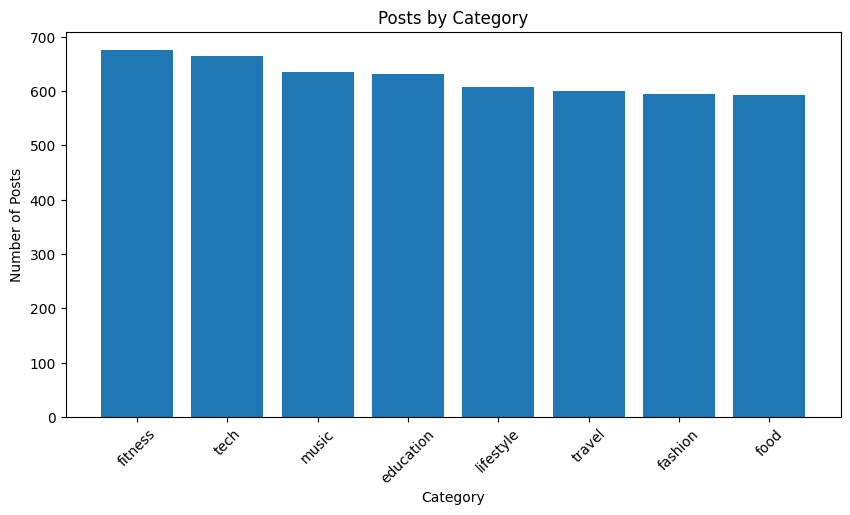

In [24]:
category_counts = df["post_category"].value_counts()

plt.figure(figsize=(10,5))

plt.bar(
    category_counts.index,
    category_counts.values
)

plt.xlabel("Category")
plt.ylabel("Number of Posts")
plt.title("Posts by Category")
plt.xticks(rotation=45)
plt.show()

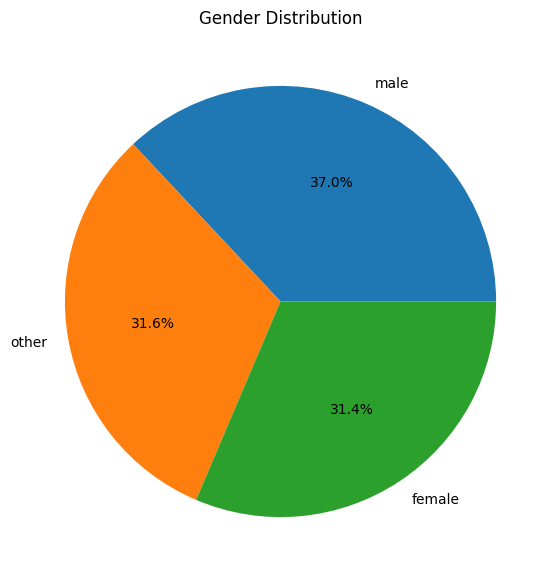

In [25]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")
plt.show()

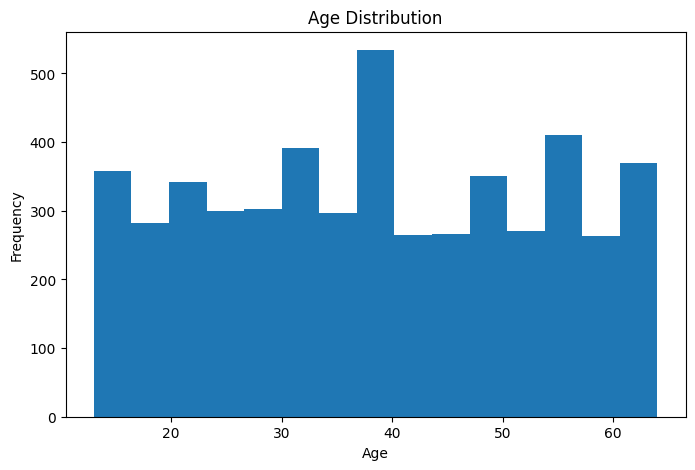

In [26]:
plt.figure(figsize=(8,5))

plt.hist(
    df["age"],
    bins=15
)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

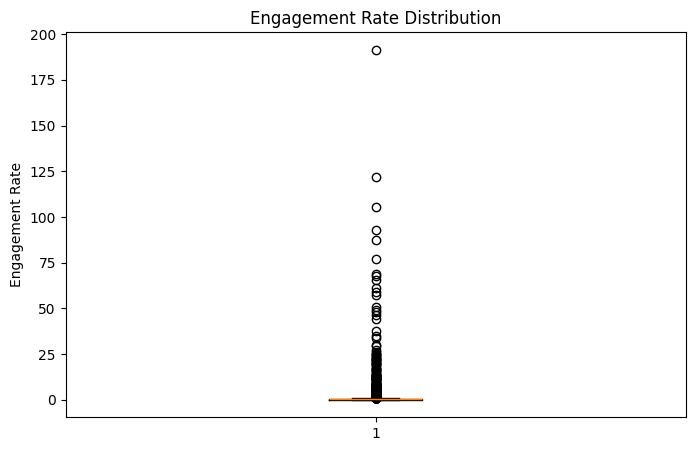

In [27]:
plt.figure(figsize=(8,5))

plt.boxplot(
    df["engagement_rate"]
)

plt.ylabel("Engagement Rate")
plt.title("Engagement Rate Distribution")
plt.show()

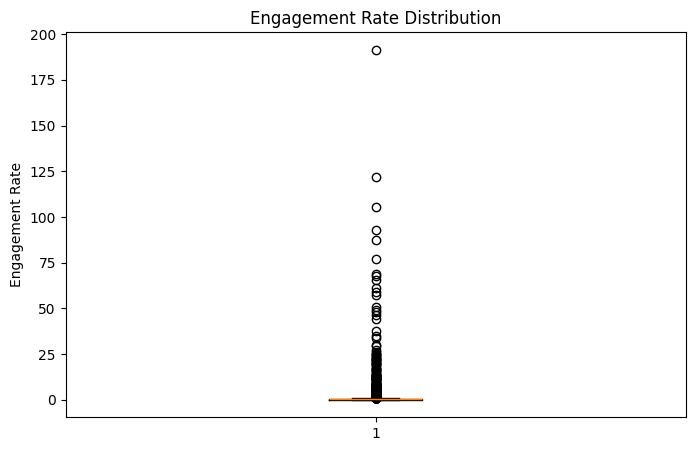

In [28]:
plt.figure(figsize=(8,5))

plt.boxplot(
    df["engagement_rate"]
)

plt.ylabel("Engagement Rate")
plt.title("Engagement Rate Distribution")
plt.show()

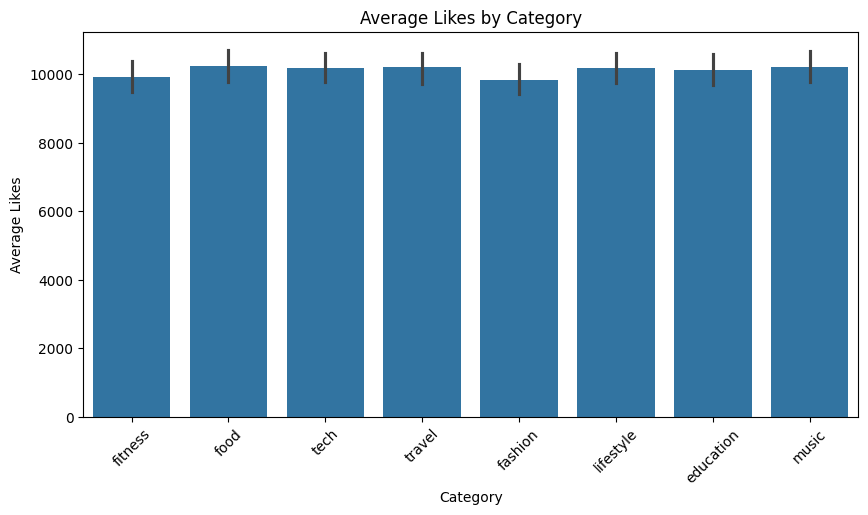

In [29]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="post_category",
    y="likes"
)

plt.title("Average Likes by Category")
plt.xlabel("Category")
plt.ylabel("Average Likes")
plt.xticks(rotation=45)
plt.show()

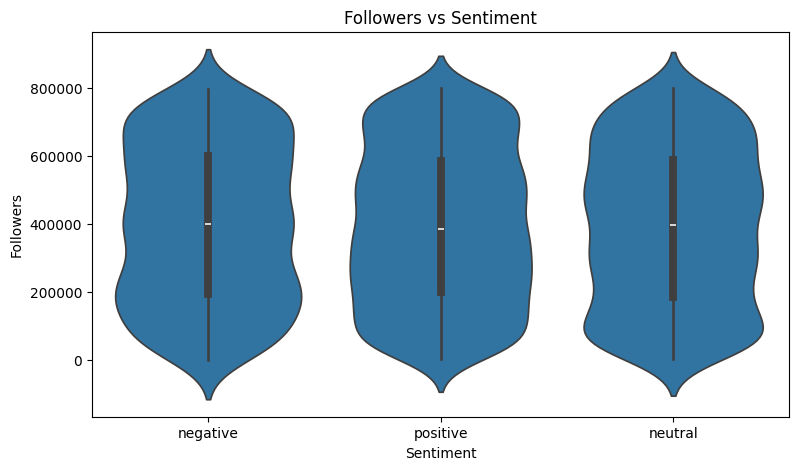

In [30]:
plt.figure(figsize=(9,5))

sns.violinplot(
    data=df,
    x="sentiment",
    y="follower_count"
)

plt.title("Followers vs Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Followers")
plt.show()

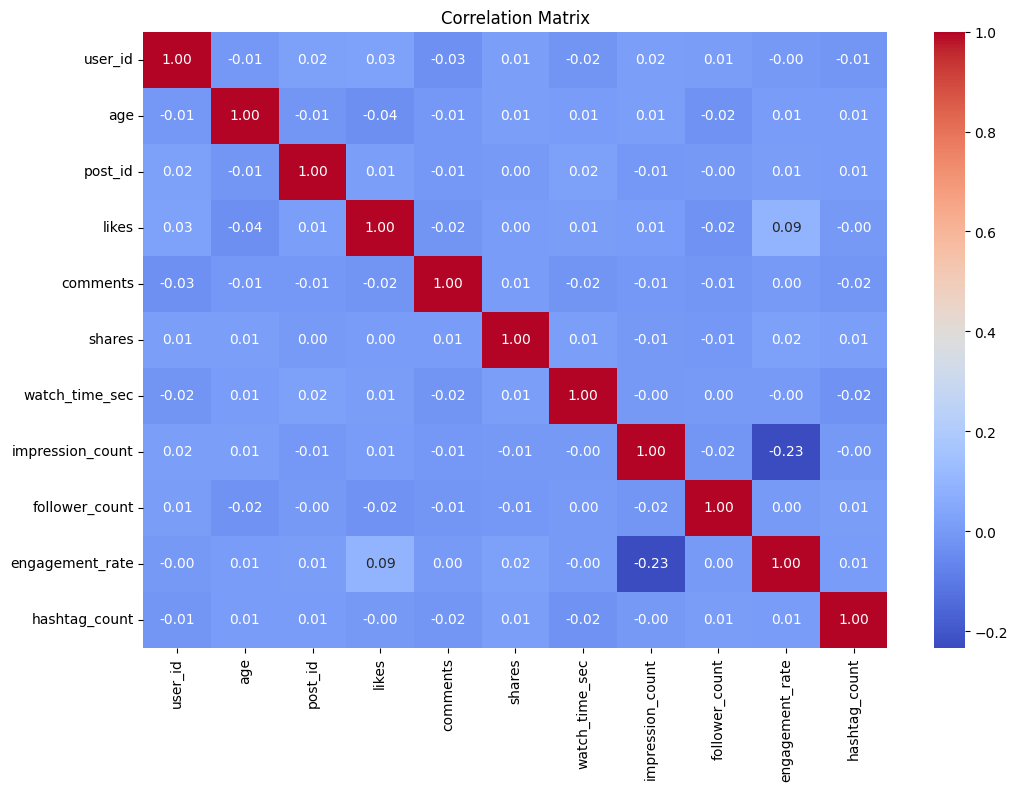

In [31]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 72.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 73.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 72.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 78.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 79.5% of the points cannot be plac

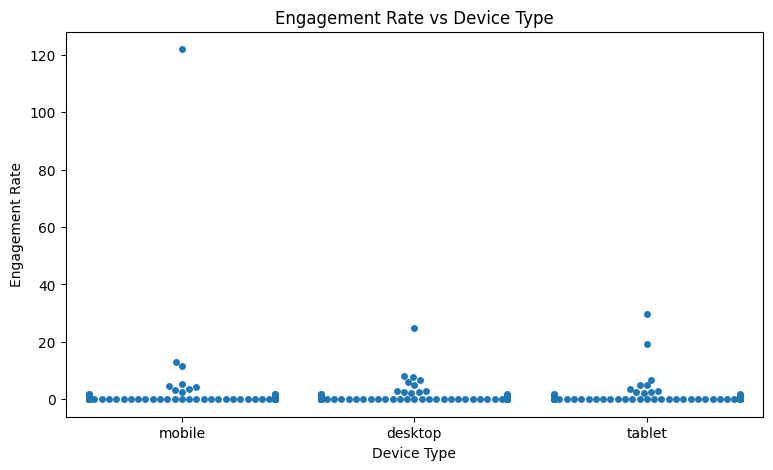

In [32]:
sample_df = df.sample(
    min(500, len(df)),
    random_state=42
)

plt.figure(figsize=(9,5))

sns.swarmplot(
    data=sample_df,
    x="device_type",
    y="engagement_rate"
)

plt.title("Engagement Rate vs Device Type")
plt.xlabel("Device Type")
plt.ylabel("Engagement Rate")
plt.show()

In [33]:
fig = px.scatter(
    df,
    x="impression_count",
    y="likes",
    color="post_type",
    size="comments",
    hover_data=[
        "country",
        "post_category",
        "sentiment"
    ],
    title="Interactive Social Media Engagement"
)

fig.show()